# Exploratory Data Analysis with Pyspark and Spark SQL

The following notebook utilizes New York City taxi data from [TLC Trip Record Data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page)

## Instructions

- Load and explore nyc taxi data from january 0f 2019. The exercises can be executed using pyspark or spark sql (a subset of the questions will be re-answered using the language not chosen for the  main work).
- Load the zone lookup table to answer the questions about the nyc boroughs.  
- Load nyc taxi data from January of 2025 and compare data.  
- With any remaining time, work on the where to go from here section.
- Note: the initial lab is opened as read only. To save work completed utilize the `save notebook as` option and give the lab a new name.

In [ ]:
import requests

# start a spark session and create a spark context
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("nyc_taxi") \
    .getOrCreate()

sc = spark.sparkContext

In [2]:
# set dl url for January 2019 trip data
download_url = 'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2019-01.parquet'

# get the data
response = requests.get(download_url)

# check that response was good and save the data
jan_2019_trip_data = "yellow_tripdata_2019-01.parquet"
if response.status_code == 200:
    # Changed 'response' to 'data' here
    with open(jan_2019_trip_data, "wb") as f:
        f.write(response.content)


In [3]:
# create the dataframe
df_trips = spark.read.parquet(jan_2019_trip_data)

# A brief note on handling data sources in spark

The command above works well for loading data from parquet files because parquet is a self descibing file format, meaning that the metadata needed to build the dataframe is included directly in the format. However, when working with other formats such as csv or json, a schema must be provided or infered. In production code the schema should always be explicitly provided but during the data exploration phase it is acceptable to infer the schema, and when infering the schema it often best to use `.option("samplingRatio", <small-portion-of-data>)` to avoid using the entire dataset for schema inference.

```python
df_trips = spark.read.format("csv") \
    .option("header", "true") \
    .option("sep", ",") \
    .option("samplingRatio", 0.01) \
    .load("large_dataset.csv")
```

In [4]:
# Show the dataframe
df_trips.show()

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|       1| 2019-01-01 00:46:40|  2019-01-01 00:53:20|            1.0|          1.5|       1.0|                 N|         151|         239|           1|        7.0|  0.5|    0.5|      1.6

## Lab

### Part 1
This section can be completed either using pyspark commands or sql commands ( There will be a section after in which a self-chosen subset of the questions are re-answered using the language not used for the main section. i.e. if pyspark is chosen for the main lab, sql should be used to repeat some of the questions. )

- Add a column that creates a unique key to identify each record in order to answer questions about individual trips
- Which trip has the highest passanger count
- What is the Average passanger count
- Shortest/longest trip by distance? by time?.
- busiest day/slowest single day
- busiest/slowest time of day ( you may want to bucket these by hour or create timess such as morning, afternoon, evening, late night )
- On average which day of the week is slowest/busiest
- Does trip distance or num passangers affect tip amount
- What was the highest "extra" charge and which trip
- Are there any datapoints that seem to be strange/outliers (make sure to explain your reasoning in a markdown cell)?

1. Add Unique Identifier Column

In [ ]:
from pyspark.sql import functions as F

df_trips = df_trips.withColumn("trip_id", F.monotonically_increasing_id())
df_trips.select("trip_id", "tpep_pickup_datetime", "passenger_count").show(5)

+-----------+--------------------+---------------+
|    trip_id|tpep_pickup_datetime|passenger_count|
+-----------+--------------------+---------------+
|25769803776| 2019-01-01 00:46:40|            1.0|
|25769803777| 2019-01-01 00:59:47|            1.0|
|25769803778| 2018-12-21 13:48:30|            3.0|
|25769803779| 2018-11-28 15:52:25|            5.0|
|25769803780| 2018-11-28 15:56:57|            5.0|
+-----------+--------------------+---------------+
only showing top 5 rows



2. Trip with Highest Passenger Count

In [7]:
max_passengers = df_trips.agg(F.max("passenger_count")).collect()[0][0]
df_trips.filter(F.col("passenger_count") == max_passengers).select("trip_id", "passenger_count", "trip_distance", "total_amount").show()

+-----------+---------------+-------------+------------+
|    trip_id|passenger_count|trip_distance|total_amount|
+-----------+---------------+-------------+------------+
|25770753732|            9.0|          0.0|        12.6|
|25771100063|            9.0|          0.0|         9.3|
|25771815874|            9.0|          0.0|        11.3|
|25772687771|            9.0|          0.0|       12.25|
|25774338483|            9.0|          0.0|      110.76|
|25774656001|            9.0|          0.0|       12.74|
|25774801566|            9.0|          0.0|         9.8|
|25777090459|            9.0|          0.0|        10.3|
|25777177652|            9.0|        13.38|        90.8|
+-----------+---------------+-------------+------------+



3. Average Passenger Count

In [8]:
df_trips.agg(F.avg("passenger_count").alias("avg_passenger_count")).show()

+-------------------+
|avg_passenger_count|
+-------------------+
| 1.5670317144945614|
+-------------------+



4. Shortest and Longest Trips by Distance and Duration

In [10]:
df_trips = df_trips.withColumn(
    "duration_minutes",
    (F.unix_timestamp(F.col("tpep_dropoff_datetime")) - F.unix_timestamp(F.col("tpep_pickup_datetime"))) / 60
)

df_trips.filter(F.col("trip_distance") > 0).orderBy(F.col("trip_distance").asc()).select("trip_id", "trip_distance").limit(1).show()
df_trips.orderBy(F.col("trip_distance").desc()).select("trip_id", "trip_distance").limit(1).show()

df_trips.filter(F.col("duration_minutes") > 0).orderBy(F.col("duration_minutes").asc()).select("trip_id", "duration_minutes").limit(1).show()
df_trips.orderBy(F.col("duration_minutes").desc()).select("trip_id", "duration_minutes").limit(1).show()

+-----------+-------------+
|    trip_id|trip_distance|
+-----------+-------------+
|25769806252|         0.01|
+-----------+-------------+

+-----------+-------------+
|    trip_id|trip_distance|
+-----------+-------------+
|25775877867|        831.8|
+-----------+-------------+

+-----------+--------------------+
|    trip_id|    duration_minutes|
+-----------+--------------------+
|25769816131|0.016666666666666666|
+-----------+--------------------+

+-----------+-----------------+
|    trip_id| duration_minutes|
+-----------+-----------------+
|25769872043|43648.01666666667|
+-----------+-----------------+



5. Busiest and Slowest Calendar Days

In [11]:
daily_counts = df_trips.withColumn("date", F.to_date("tpep_pickup_datetime")).groupBy("date").count()

daily_counts.orderBy(F.col("count").asc()).limit(1).show()
daily_counts.orderBy(F.col("count").desc()).limit(1).show()

+----------+-----+
|      date|count|
+----------+-----+
|2019-02-23|    1|
+----------+-----+

+----------+------+
|      date| count|
+----------+------+
|2019-01-25|292499|
+----------+------+



6. Busiest and Slowest Hours of the Day

In [12]:
hourly_counts = df_trips.withColumn("hour", F.hour("tpep_pickup_datetime")).groupBy("hour").count()

hourly_counts.orderBy(F.col("count").asc()).limit(1).show()
hourly_counts.orderBy(F.col("count").desc()).limit(1).show()

+----+-----+
|hour|count|
+----+-----+
|   4|61424|
+----+-----+

+----+------+
|hour| count|
+----+------+
|  18|515390|
+----+------+



7. Slowest and Busiest Days of the Week on Average

In [13]:
dow_avg = df_trips.withColumn("date", F.to_date("tpep_pickup_datetime")) \
    .withColumn("day_of_week", F.dayofweek("tpep_pickup_datetime")) \
    .groupBy("day_of_week", "date") \
    .count() \
    .groupBy("day_of_week") \
    .agg(F.avg("count").alias("avg_trips"))

dow_avg.orderBy(F.col("avg_trips").asc()).limit(1).show()
dow_avg.orderBy(F.col("avg_trips").desc()).limit(1).show()

+-----------+---------+
|day_of_week|avg_trips|
+-----------+---------+
|          2|  90812.1|
+-----------+---------+

+-----------+-----------------+
|day_of_week|        avg_trips|
+-----------+-----------------+
|          5|193863.2857142857|
+-----------+-----------------+



8. Impact of Distance and Passenger Count on Tip Amount

In [14]:
df_trips.select(
    F.corr("trip_distance", "tip_amount").alias("corr_distance_tip"),
    F.corr("passenger_count", "tip_amount").alias("corr_passengers_tip")
).show()

+------------------+--------------------+
| corr_distance_tip| corr_passengers_tip|
+------------------+--------------------+
|0.5269200663652668|0.001084223312167...|
+------------------+--------------------+



9. Highest Extra Charge and Trip Identification

In [15]:
max_extra = df_trips.agg(F.max("extra")).collect()[0][0]
df_trips.filter(F.col("extra") == max_extra).select("trip_id", "extra", "total_amount", "trip_distance").show()

+-----------+------+------------+-------------+
|    trip_id| extra|total_amount|trip_distance|
+-----------+------+------------+-------------+
|25775127259|535.38|   356214.78|          0.0|
+-----------+------+------------+-------------+



10. Outliers and Anomalies Detection

In [16]:
df_trips.filter(
    (F.col("trip_distance") <= 0) |
    (F.col("duration_minutes") <= 0) |
    (F.col("duration_minutes") > 1440) |
    (F.col("passenger_count") == 0) |
    (F.col("total_amount") < 0) |
    (F.col("fare_amount") < 0)
).select("trip_id", "trip_distance", "duration_minutes", "passenger_count", "total_amount").show(10)

+-----------+-------------+------------------+---------------+------------+
|    trip_id|trip_distance|  duration_minutes|passenger_count|total_amount|
+-----------+-------------+------------------+---------------+------------+
|25769803778|          0.0| 4.166666666666667|            3.0|         5.8|
|25769803779|          0.0|3.3333333333333335|            5.0|        7.55|
|25769803780|          0.0|               1.6|            5.0|       55.55|
|25769803781|          0.0|2.6166666666666667|            5.0|       13.31|
|25769803782|          0.0|               4.1|            5.0|       55.55|
|25769803804|          0.0|               0.0|            3.0|         7.8|
|25769803932|          5.3|              0.95|            0.0|        4.55|
|25769804004|         18.0|30.966666666666665|            0.0|        59.8|
|25769804005|          8.9|31.316666666666666|            0.0|        38.5|
|25769804074|          1.0|10.566666666666666|            0.0|         9.3|
+-----------

### Part 2

- Using the code for loading the first dataset as an example, load in the taxi zone lookup and answer the following questions
- which borough had most pickups? dropoffs?
- what are the busy/slow times by borough 
- what are the busiest days of the week by borough?
- what is the average trip distance by borough?
- what is the average trip fare by borough?
- highest/lowest faire amounts for a trip, what burough is associated with the each
- load the dataset from the most recently available january, is there a change to any of the average metrics.

In [17]:
import requests
from pyspark.sql import functions as F

lookup_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi+_zone_lookup.csv"
response = requests.get(lookup_url)

lookup_file = "taxi_zone_lookup.csv"
if response.status_code == 200:
    with open(lookup_file, "wb") as f:
        f.write(response.content)

df_zones = spark.read.option("header", "true").csv(lookup_file)
df_zones.show(5)

+----------+-------------+--------------------+------------+
|LocationID|      Borough|                Zone|service_zone|
+----------+-------------+--------------------+------------+
|         1|          EWR|      Newark Airport|         EWR|
|         2|       Queens|         Jamaica Bay|   Boro Zone|
|         3|        Bronx|Allerton/Pelham G...|   Boro Zone|
|         4|    Manhattan|       Alphabet City| Yellow Zone|
|         5|Staten Island|       Arden Heights|   Boro Zone|
+----------+-------------+--------------------+------------+
only showing top 5 rows



Join Trips with Pickup and Dropoff Zones

In [18]:
df_joined = df_trips.join(
    df_zones.withColumnRenamed("Borough", "pickup_borough")
            .withColumnRenamed("Zone", "pickup_zone")
            .withColumnRenamed("service_zone", "pickup_service_zone"),
    df_trips.PULocationID == df_zones.LocationID,
    "left"
).drop("LocationID")

df_joined = df_joined.join(
    df_zones.withColumnRenamed("Borough", "dropoff_borough")
            .withColumnRenamed("Zone", "dropoff_zone")
            .withColumnRenamed("service_zone", "dropoff_service_zone"),
    df_joined.DOLocationID == df_zones.LocationID,
    "left"
).drop("LocationID")

1. Boroughs with Most Pickups and Dropoffs

In [19]:
df_joined.groupBy("pickup_borough").count().orderBy(F.col("count").desc()).show()
df_joined.groupBy("dropoff_borough").count().orderBy(F.col("count").desc()).show()

+--------------+-------+
|pickup_borough|  count|
+--------------+-------+
|     Manhattan|6950965|
|        Queens| 471173|
|       Unknown| 159815|
|      Brooklyn|  91905|
|         Bronx|  18062|
|           N/A|   3890|
|           EWR|    446|
| Staten Island|    361|
+--------------+-------+

+---------------+-------+
|dropoff_borough|  count|
+---------------+-------+
|      Manhattan|6817355|
|         Queens| 340972|
|       Brooklyn| 301105|
|        Unknown| 149097|
|          Bronx|  58085|
|            N/A|  16904|
|            EWR|  10914|
|  Staten Island|   2185|
+---------------+-------+



2. Busiest and Slowest Hours by Borough

In [20]:
df_borough_hours = df_joined.withColumn("hour", F.hour("tpep_pickup_datetime")) \
    .filter(F.col("pickup_borough").isNotNull()) \
    .groupBy("pickup_borough", "hour") \
    .count()

from pyspark.sql.window import Window

window_borough_desc = Window.partitionBy("pickup_borough").orderBy(F.col("count").desc())
window_borough_asc = Window.partitionBy("pickup_borough").orderBy(F.col("count").asc())

busiest_hours = df_borough_hours.withColumn("rank", F.row_number().over(window_borough_desc)).filter(F.col("rank") == 1)
slowest_hours = df_borough_hours.withColumn("rank", F.row_number().over(window_borough_asc)).filter(F.col("rank") == 1)

busiest_hours.select("pickup_borough", "hour", "count").show()
slowest_hours.select("pickup_borough", "hour", "count").show()

+--------------+----+------+
|pickup_borough|hour| count|
+--------------+----+------+
|         Bronx|   7|  1803|
|      Brooklyn|   8|  6935|
|           EWR|  15|    54|
|     Manhattan|  18|471539|
|           N/A|  19|   214|
|        Queens|  16| 29885|
| Staten Island|   8|    36|
|       Unknown|  18| 10751|
+--------------+----+------+

+--------------+----+-----+
|pickup_borough|hour|count|
+--------------+----+-----+
|         Bronx|   3|  225|
|      Brooklyn|   3| 1919|
|           EWR|  23|    1|
|     Manhattan|   4|53447|
|           N/A|   6|   88|
|        Queens|   3| 3085|
| Staten Island|   1|    3|
|       Unknown|   4| 1465|
+--------------+----+-----+



3. Busiest Days of the Week by Borough

In [21]:
df_borough_dow = df_joined.withColumn("day_of_week", F.dayofweek("tpep_pickup_datetime")) \
    .filter(F.col("pickup_borough").isNotNull()) \
    .groupBy("pickup_borough", "day_of_week") \
    .count()

busiest_dow = df_borough_dow.withColumn("rank", F.row_number().over(window_borough_desc)).filter(F.col("rank") == 1)
busiest_dow.select("pickup_borough", "day_of_week", "count").show()

+--------------+-----------+-------+
|pickup_borough|day_of_week|  count|
+--------------+-----------+-------+
|         Bronx|          5|   3121|
|      Brooklyn|          3|  15779|
|           EWR|          4|     83|
|     Manhattan|          5|1229554|
|           N/A|          3|    703|
|        Queens|          5|  78972|
| Staten Island|          6|     64|
|       Unknown|          5|  28929|
+--------------+-----------+-------+



4. Average Trip Distance by Borough

In [22]:
df_joined.filter(F.col("pickup_borough").isNotNull()) \
    .groupBy("pickup_borough") \
    .agg(F.avg("trip_distance").alias("avg_distance")) \
    .orderBy(F.col("avg_distance").desc()) \
    .show()

+--------------+------------------+
|pickup_borough|      avg_distance|
+--------------+------------------+
| Staten Island|12.503601108033246|
|        Queens|11.283218499361993|
|         Bronx| 7.233194552098303|
|      Brooklyn| 4.787677275447492|
|           N/A| 3.193850899742941|
|           EWR| 2.641098654708519|
|       Unknown| 2.415464130400774|
|     Manhattan|2.2286693358402596|
+--------------+------------------+



5. Average Trip Fare by Borough

In [23]:
df_joined.filter(F.col("pickup_borough").isNotNull()) \
    .groupBy("pickup_borough") \
    .agg(F.avg("fare_amount").alias("avg_fare")) \
    .orderBy(F.col("avg_fare").desc()) \
    .show()

+--------------+------------------+
|pickup_borough|          avg_fare|
+--------------+------------------+
|           EWR| 76.24024663677126|
|           N/A|  59.5731593830335|
| Staten Island|45.289861495844896|
|        Queens| 35.14462651722029|
|         Bronx| 26.26890543682963|
|      Brooklyn|18.649132800172286|
|       Unknown|14.944423051653523|
|     Manhattan|10.792468572351568|
+--------------+------------------+



6. Highest and Lowest Fare Amounts and Associated Boroughs

In [24]:
df_positive_fare = df_joined.filter(F.col("fare_amount") > 0)

max_fare = df_positive_fare.agg(F.max("fare_amount")).collect()[0][0]
min_fare = df_positive_fare.agg(F.min("fare_amount")).collect()[0][0]

df_positive_fare.filter(F.col("fare_amount") == max_fare) \
    .select("trip_id", "fare_amount", "pickup_borough", "dropoff_borough") \
    .show()

df_positive_fare.filter(F.col("fare_amount") == min_fare) \
    .select("trip_id", "fare_amount", "pickup_borough", "dropoff_borough") \
    .show(5)

+-----------+-----------+--------------+---------------+
|    trip_id|fare_amount|pickup_borough|dropoff_borough|
+-----------+-----------+--------------+---------------+
|25772303431|  623259.86|     Manhattan|      Manhattan|
+-----------+-----------+--------------+---------------+

+-----------+-----------+--------------+---------------+
|    trip_id|fare_amount|pickup_borough|dropoff_borough|
+-----------+-----------+--------------+---------------+
|25769805814|       0.01|           N/A|            N/A|
|25769814043|       0.01|     Manhattan|            N/A|
|25769815296|       0.01|           N/A|            N/A|
|25769821147|       0.01|     Manhattan|      Manhattan|
|25769825313|       0.01|     Manhattan|      Manhattan|
+-----------+-----------+--------------+---------------+
only showing top 5 rows



7. Comparison with Recent January Dataset

In [25]:
jan_recent_url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
jan_recent_file = "yellow_tripdata_2024-01.parquet"

response_recent = requests.get(jan_recent_url)
if response_recent.status_code == 200:
    with open(jan_recent_file, "wb") as f:
        f.write(response_recent.content)

df_recent = spark.read.parquet(jan_recent_file)

df_recent_joined = df_recent.join(
    df_zones.withColumnRenamed("Borough", "pickup_borough"),
    df_recent.PULocationID == df_zones.LocationID,
    "left"
)

metrics_2019 = df_joined.filter(F.col("fare_amount") > 0).agg(
    F.avg("trip_distance").alias("avg_distance_2019"),
    F.avg("fare_amount").alias("avg_fare_2019"),
    F.avg("passenger_count").alias("avg_passengers_2019")
)

metrics_recent = df_recent_joined.filter(F.col("fare_amount") > 0).agg(
    F.avg("trip_distance").alias("avg_distance_recent"),
    F.avg("fare_amount").alias("avg_fare_recent"),
    F.avg("passenger_count").alias("avg_passengers_recent")
)

metrics_2019.show()
metrics_recent.show()

+-----------------+------------------+-------------------+
|avg_distance_2019|     avg_fare_2019|avg_passengers_2019|
+-----------------+------------------+-------------------+
|2.831857993271013|12.554838882578709| 1.5671100233286508|
+-----------------+------------------+-------------------+

+-------------------+-----------------+---------------------+
|avg_distance_recent|  avg_fare_recent|avg_passengers_recent|
+-------------------+-----------------+---------------------+
|    3.6609030397949|18.65728024254823|   1.3393771763304196|
+-------------------+-----------------+---------------------+



### Part 3

- choose 3 questions from above and re-answer them using the language you did not use for the main notebook . (i.e - if you completed the exercise in python, redo 3 questions in pure sql) . at least one of the questions to be redone must involve a join

In [26]:
df_trips.createOrReplaceTempView("trips")
df_zones.createOrReplaceTempView("zones")

1. Trip with Highest Passenger Count (SQL Version)

In [27]:
spark.sql("""
    SELECT trip_id, passenger_count, trip_distance, total_amount
    FROM trips
    WHERE passenger_count = (SELECT MAX(passenger_count) FROM trips)
""").show()

+-----------+---------------+-------------+------------+
|    trip_id|passenger_count|trip_distance|total_amount|
+-----------+---------------+-------------+------------+
|25770753732|            9.0|          0.0|        12.6|
|25771100063|            9.0|          0.0|         9.3|
|25771815874|            9.0|          0.0|        11.3|
|25772687771|            9.0|          0.0|       12.25|
|25774338483|            9.0|          0.0|      110.76|
|25774656001|            9.0|          0.0|       12.74|
|25774801566|            9.0|          0.0|         9.8|
|25777090459|            9.0|          0.0|        10.3|
|25777177652|            9.0|        13.38|        90.8|
+-----------+---------------+-------------+------------+



2. Slowest and Busiest Days of the Week on Average (SQL Version)

In [28]:
spark.sql("""
    WITH daily_trips AS (
        SELECT 
            DAYOFWEEK(tpep_pickup_datetime) AS day_of_week,
            TO_DATE(tpep_pickup_datetime) AS trip_date,
            COUNT(*) AS trip_count
        FROM trips
        GROUP BY DAYOFWEEK(tpep_pickup_datetime), TO_DATE(tpep_pickup_datetime)
    )
    SELECT 
        day_of_week,
        AVG(trip_count) AS avg_trips
    FROM daily_trips
    GROUP BY day_of_week
    ORDER BY avg_trips DESC
""").show()

+-----------+------------------+
|day_of_week|         avg_trips|
+-----------+------------------+
|          5| 193863.2857142857|
|          6|155316.42857142858|
|          7|144283.57142857142|
|          4|140584.88888888888|
|          3|          120908.4|
|          1|        107488.125|
|          2|           90812.1|
+-----------+------------------+



3. Boroughs with Most Pickups and Dropoffs (SQL Version with Join)

In [29]:
spark.sql("""
    SELECT 
        z.Borough AS pickup_borough,
        COUNT(*) AS total_pickups
    FROM trips t
    JOIN zones z ON t.PULocationID = z.LocationID
    GROUP BY z.Borough
    ORDER BY total_pickups DESC
""").show()

spark.sql("""
    SELECT 
        z.Borough AS dropoff_borough,
        COUNT(*) AS total_dropoffs
    FROM trips t
    JOIN zones z ON t.DOLocationID = z.LocationID
    GROUP BY z.Borough
    ORDER BY total_dropoffs DESC
""").show()

+--------------+-------------+
|pickup_borough|total_pickups|
+--------------+-------------+
|     Manhattan|      6950965|
|        Queens|       471173|
|       Unknown|       159815|
|      Brooklyn|        91905|
|         Bronx|        18062|
|           N/A|         3890|
|           EWR|          446|
| Staten Island|          361|
+--------------+-------------+

+---------------+--------------+
|dropoff_borough|total_dropoffs|
+---------------+--------------+
|      Manhattan|       6817355|
|         Queens|        340972|
|       Brooklyn|        301105|
|        Unknown|        149097|
|          Bronx|         58085|
|            N/A|         16904|
|            EWR|         10914|
|  Staten Island|          2185|
+---------------+--------------+



# Where to go from here

- Continue building the dataset by loading in more data, start by completing the data for 2019 and calculating the busiest season (fall, winter, spring, summer)
- As of spark v4 dataframes have native visualization support. Choose at least 3 questions from above and provide visualizations.
- Explore a dataset/datasets of your choosing

1. Download Full Year 2019 and Determine the Busiest Season

In [30]:
import requests
from pyspark.sql import functions as F

months = [f"{i:02d}" for i in range(2, 13)]
base_url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2019-"

for m in months:
    url = f"{base_url}{m}.parquet"
    resp = requests.get(url)
    if resp.status_code == 200:
        with open(f"yellow_tripdata_2019-{m}.parquet", "wb") as f:
            f.write(resp.content)

df_all_2019 = spark.read.parquet("yellow_tripdata_2019-*.parquet")

df_seasons = df_all_2019.withColumn("month", F.month("tpep_pickup_datetime")) \
    .withColumn("season", 
        F.when(F.col("month").isin(12, 1, 2), "Winter")
         .when(F.col("month").isin(3, 4, 5), "Spring")
         .when(F.col("month").isin(6, 7, 8), "Summer")
         .otherwise("Fall")
    )

df_seasons.groupBy("season").count().orderBy(F.col("count").desc()).show()

+------+--------+
|season|   count|
+------+--------+
|Spring|22941027|
|Winter|21643025|
|  Fall|20659565|
|Summer|19354827|
+------+--------+



2. Native Dataframe Visualizations

Visualization 1: Trips per Hour of the Day

<Axes: xlabel='hour'>

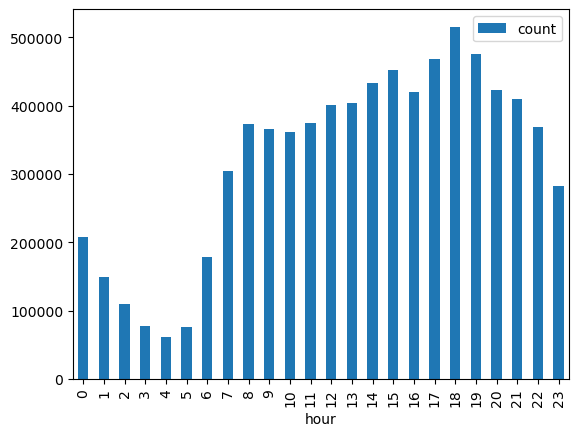

In [33]:
hourly_df = df_trips.withColumn("hour", F.hour("tpep_pickup_datetime")).groupBy("hour").count().orderBy("hour")
hourly_df.toPandas().plot(kind="bar", x="hour", y="count")

Visualization 2: Pickups by Borough

<Axes: xlabel='pickup_borough'>

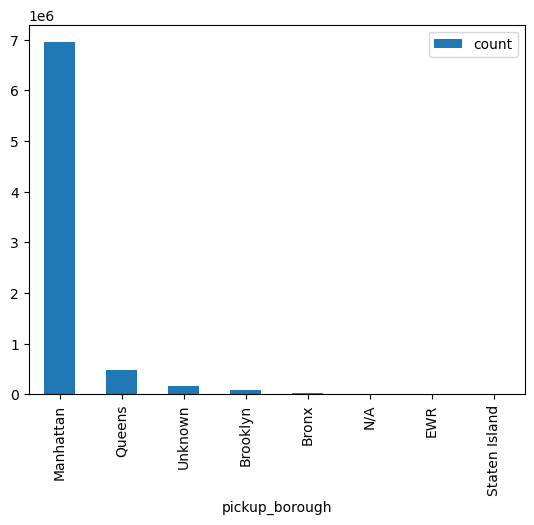

In [34]:
borough_df = df_joined.filter(F.col("pickup_borough").isNotNull()).groupBy("pickup_borough").count().orderBy(F.col("count").desc())
borough_df.toPandas().plot(kind="bar", x="pickup_borough", y="count")

Visualization 3: Average Tip Amount by Passenger Count

<Axes: xlabel='passenger_count'>

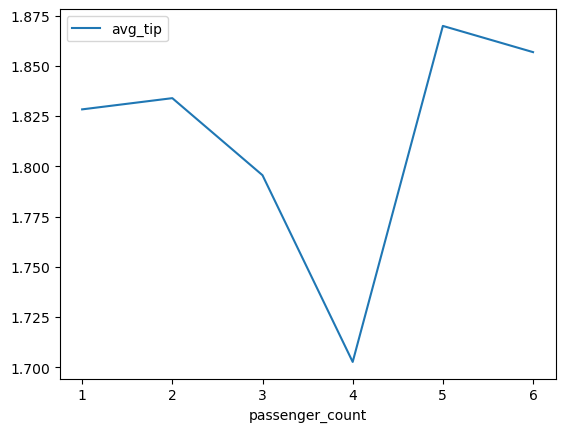

In [35]:
tips_passenger_df = df_trips.filter((F.col("passenger_count") > 0) & (F.col("passenger_count") <= 6)) \
    .groupBy("passenger_count") \
    .agg(F.avg("tip_amount").alias("avg_tip")) \
    .orderBy("passenger_count")

tips_passenger_df.toPandas().plot(kind="line", x="passenger_count", y="avg_tip")